<a href="https://colab.research.google.com/github/yumnazakkiya/DQLAB_ML_AI/blob/main/SESI08/Quiz_ML_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

from sklearn import datasets
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load Data Iris

In [ ]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                       columns= iris['feature_names'] + ['target'])
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


# EDA

<Axes: xlabel='target'>

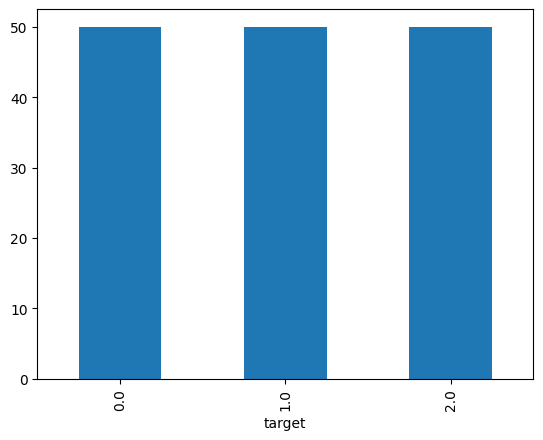

In [ ]:
jml_category = iris_df.target.value_counts()
jml_category.plot(kind='bar')

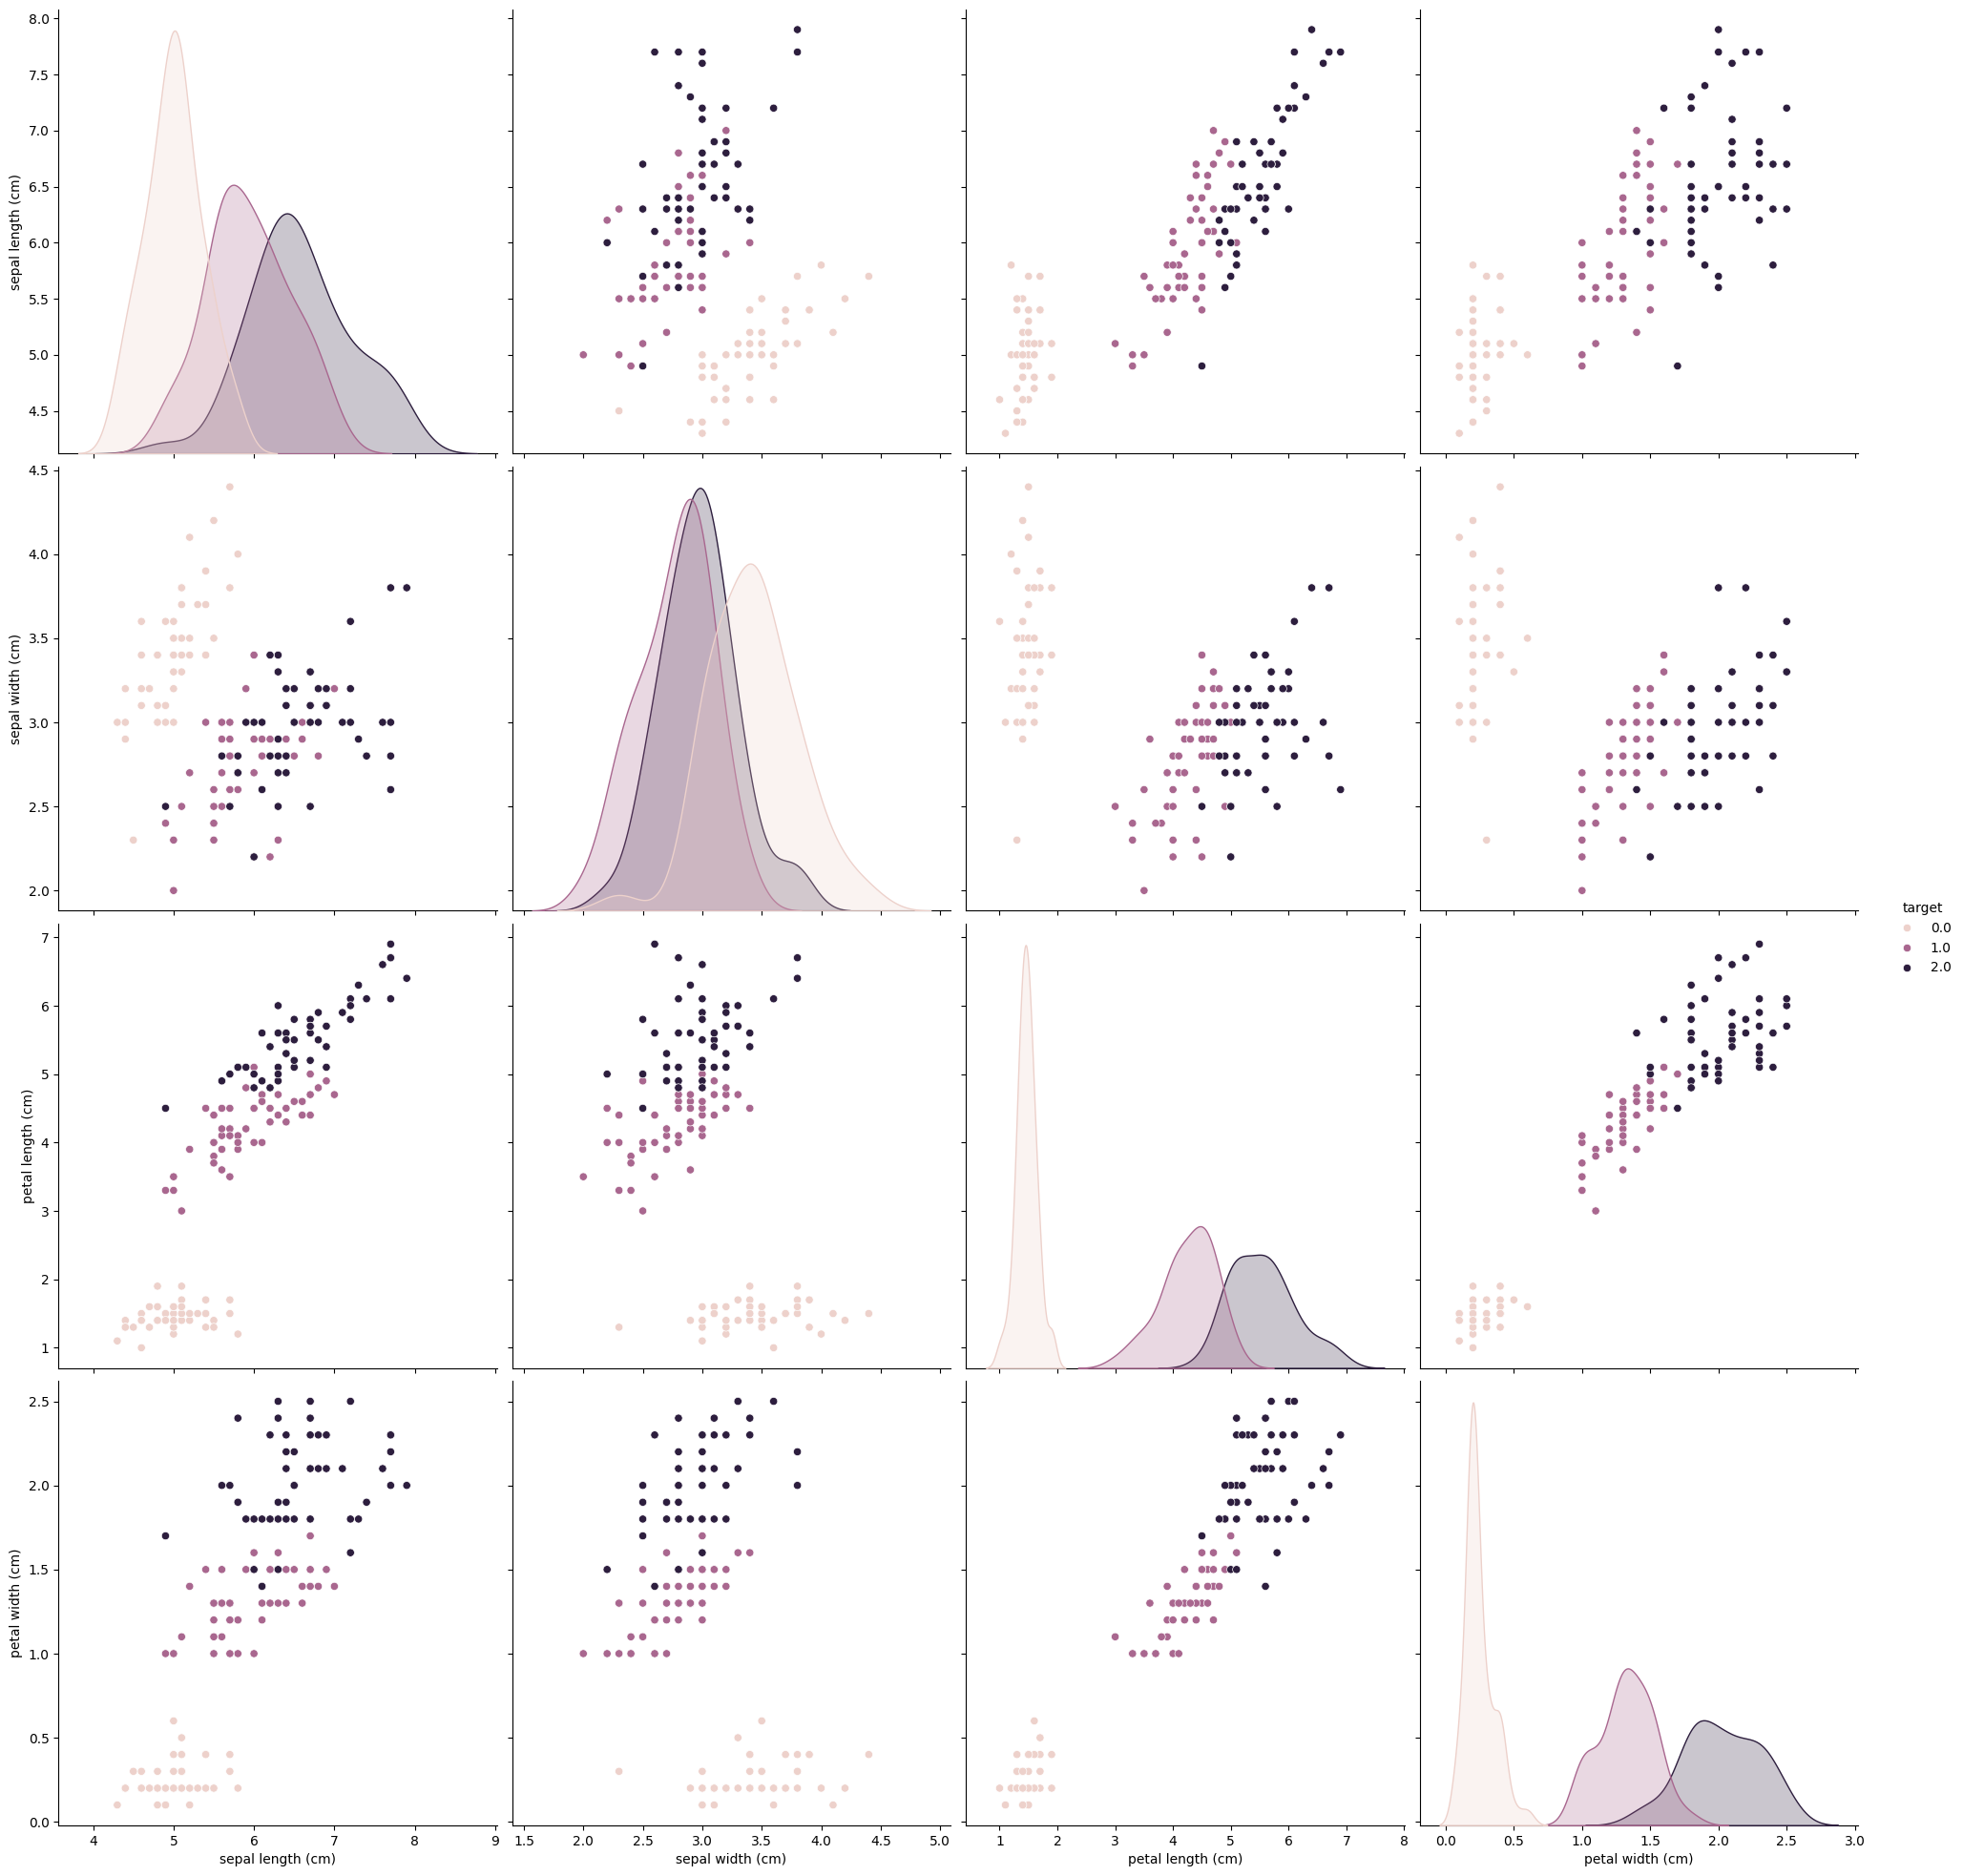

In [ ]:
sns.pairplot(iris_df, hue = "target", height = 5)

# Data Preprocessing
## Pemisahan Features (X) dan Target (Y)

In [ ]:
X = iris_df.drop(["target"], axis = 1)
y = iris_df["target"]
print(X.shape, y.shape)

(150, 4) (150,)


## Scaling Nilai Features (X)

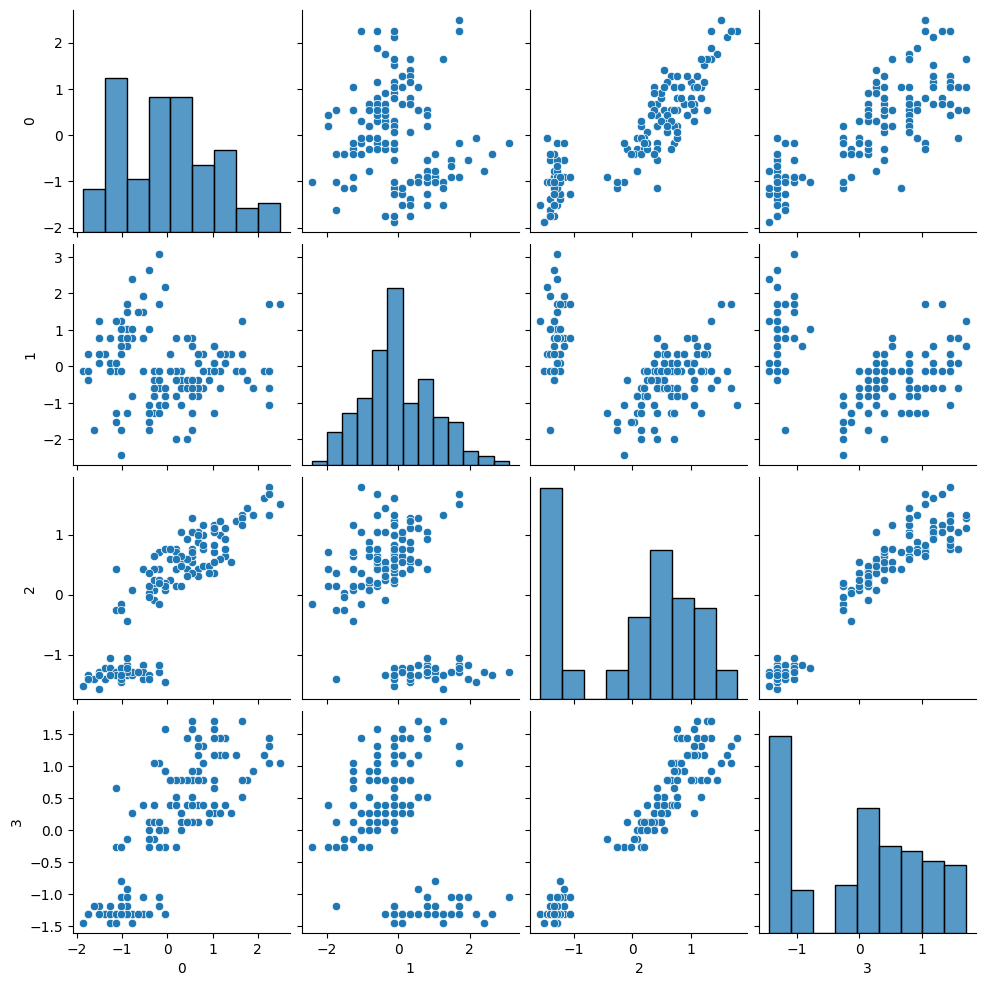

In [ ]:
sc = StandardScaler()
X = sc.fit_transform(X)
sns.pairplot(pd.DataFrame(X))

# Clustering
## K-means

In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


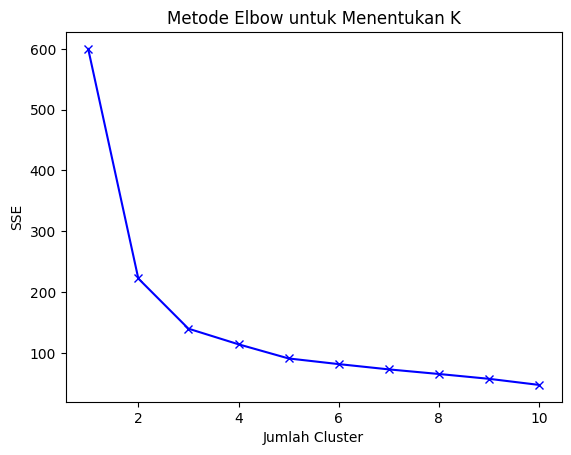

In [ ]:
from sklearn.cluster import KMeans

# Elbow Method
sse = []
range_n_clusters = range(1, 11)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(range_n_clusters, sse, 'bx-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Menentukan K')
plt.show()

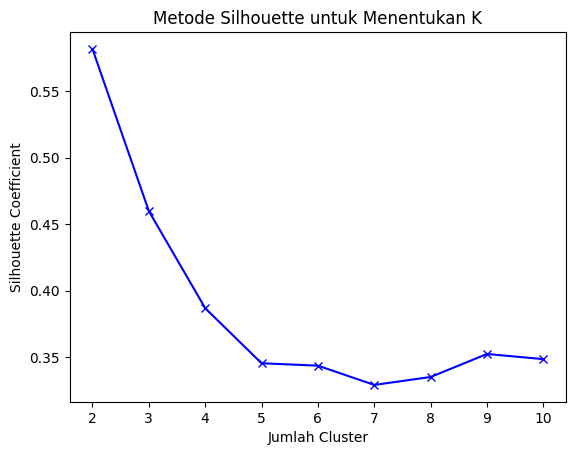

In [ ]:
# Silhouette Method
silhouette_scores = []
range_n_clusters = range(2, 11)
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    kmeans.fit(X)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

plt.plot(range_n_clusters, silhouette_scores, 'bx-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Coefficient')
plt.title('Metode Silhouette untuk Menentukan K')
plt.show()

In [ ]:
iris_df.target.unique()

array([0., 1., 2.])

# Quiz
**Dari 2 plot nilai evaluasi tersebut, tentukan jumlah cluster yang paling optimal. Berikan alasannya?**

- jumlah cluster paling optimal adalah 3, karena nilai elbow SSE pada grafik pertama ada pada nilai 3. sedangkan pada grafik silhoutte score, jumlah cluster 3 merupakan nilai tertinggi kedua setelah nilai 2.

**Membandingkan hasil clustering unsupervised dengan true label yang ada pada data**

In [ ]:
y

In [ ]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
from sklearn.metrics import classification_report

# clustering
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)
print(classification_report(labels, y))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.00      0.00      0.00        50
           2       0.72      0.77      0.74        47

    accuracy                           0.24       150
   macro avg       0.24      0.26      0.25       150
weighted avg       0.23      0.24      0.23       150



In [ ]:
gabung = pd.DataFrame(zip(labels,y), columns=['cluster','true_label'])
gabung.groupby(by=['true_label','cluster'])['cluster'].count()

true_label  cluster
0.0         1          50
1.0         0          39
            2          11
2.0         0          14
            2          36
Name: cluster, dtype: int64

**tarik kesimpulan pada report di atas**

karena kasus yang berbeda, antara clustering dan classification. Sebenarnya, pendekatan classification report tidak tepat digunakan. Bisa dilihat dari hasil report yang menunjukan angka yang sangat kecil hingga 0 tersebut. Hal ini disebabkan oleh label atas hasil clustering tidak menunjukan label yang sama dengan label classifikasi. Label hasil clustering perlu dianalisis lebih lanjut untuk didefinisikan secara tepat.

misalnya, label 1 pada data iris menunjukan type bunga iris kedua, sedangkan label 1 pada hasil clustering hanya menunjukan bahwa seluruh baris dengan label 1 merupakan baris dengan kemiripan data namun bukan berarti anggota cluster 1 adalah type bunga iris kedua sebagaimana pada data asli.

# Hierarchical Clustering

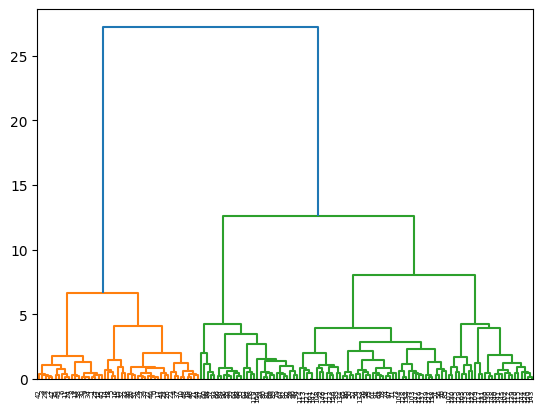

In [ ]:
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

In [ ]:
# Silhouette Method
silhouette_scores = []
range_n_clusters = range(2, 11)
for n_clusters in range_n_clusters:
    hierarchical_cluster = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
    labels = hierarchical_cluster.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(range_n_clusters, silhouette_scores, 'bx-')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Coefficient')
plt.title('Metode Silhouette untuk Menentukan K')
plt.show()

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

# Quiz
**Dari dendogram dan diagram Silhouette Coef yang ditampilkan, tentukan jumlah cluster dengan pendekatan hierarchical yang paling optimal?**

- nilai cluster yang paling optimal adalah 2, hal ini dapat dilihat dari dendogram yang menghasilkan 2 kelompok besar percabangan dengan warna hijau dan orange. Sedangkan pada diagram Silhouette Coef, nilai coefisien pada cluster 2 merupakan nilai tertinggi
- Tetapi, 3 cluster juga masih dinilai baik karena jika percabangan pada dendogram dendogram dibagi menjadi 3 kelompok, cluster berwarna hijau dapat dibagi menjadi 2 cluster baru. walaupun hasil pembagian nya terlihat tidak seimbang karena akan menghasilkan 1 cluster yang lebih kecil daripada cluster lain.
